<a href="https://colab.research.google.com/github/AditiAICodes/NASA-CMAPSS-RUL-Engine-Degradation-Investigation/blob/main/Engine_failure_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np


columns = ['unit_number', 'time_cycles', 'setting_1', 'setting_2', 'setting_3']
sensors = [f'sensor_{i}' for i in range(1, 22)]
columns.extend(sensors)


df_train = pd.read_csv('train_FD001.txt', sep='\s+', names=columns)



<>:10: SyntaxWarning: invalid escape sequence '\s'
<>:10: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_7470/2701774658.py:10: SyntaxWarning: invalid escape sequence '\s'
  df_train = pd.read_csv('train_FD001.txt', sep='\s+', names=columns)


In [2]:
print(f"Dataset Shape: {df_train.shape}")
df_train.head()

Dataset Shape: (20631, 26)


,unit_number,time_cycles,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [3]:
# 🔵 Phase 1: EDA & Understanding
# In Linear Algebra, we have just loaded a 20631 x 26 Matrix.
# We group the data by 'unit_number' and look at the 'time_cycles' column
# Then we find the maximum value for each engine
max_cycles = df_train.groupby('unit_number')['time_cycles'].max()

#To know how many engines and what is the
print("Life expectancy of the first 5 engines:")
print(max_cycles.head(20631))

# Average life of an engine
print(f"\nAverage engine life: {max_cycles.mean():.2f} cycles")

Life expectancy of the first 5 engines:
unit_number
1      192
2      287
3      179
4      189
5      269
      ... 
96     336
97     202
98     156
99     185
100    200
Name: time_cycles, Length: 100, dtype: int64

Average engine life: 206.31 cycles


In [4]:
# nunique() counts how many Number of Unique values exist
# Variance measures how spread out the numbers are.
num_engines = df_train['unit_number'].nunique()

print(f"Total number of unique engines: {num_engines}")

#  To see the actual list of IDs :
unique_ids = df_train['unit_number'].unique()
print(f"Engine IDs: {unique_ids}")

Total number of unique engines: 100
Engine IDs: [  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54
  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72
  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90
  91  92  93  94  95  96  97  98  99 100]


In [5]:
# Constant features contain zero information as when sensor changes → engine condition changes
# Count how many unique values each column has
unique_counts = df_train.nunique()
print("Unique values per column:")
print(unique_counts)

#Find columns where unique count = 1 (constant columns) as unique count = 1 → no variation → useless feature
# Less dimensions = faster training and less chance of the model getting confused by random static.
columns_to_drop = unique_counts[unique_counts == 1].index
df_train_clean = df_train.drop(columns=columns_to_drop)

print(f"\nNew Dataset Shape after cleaning: {df_train_clean.shape}")

Unique values per column:
unit_number     100
time_cycles     362
setting_1       158
setting_2        13
setting_3         1
sensor_1          1
sensor_2        310
sensor_3       3012
sensor_4       4051
sensor_5          1
sensor_6          2
sensor_7        513
sensor_8         53
sensor_9       6403
sensor_10         1
sensor_11       159
sensor_12       427
sensor_13        56
sensor_14      6078
sensor_15      1918
sensor_16         1
sensor_17        13
sensor_18         1
sensor_19         1
sensor_20       120
sensor_21      4745
dtype: int64

New Dataset Shape after cleaning: (20631, 19)


In [6]:
# sort your data by Time before doing time-math.

df_train_clean = df_train_clean.sort_values(by=['unit_number', 'time_cycles'])

# Calculate the difference between the current flight and the previous flight
df_train_clean['cycle_gap'] = df_train_clean.groupby('unit_number')['time_cycles'].diff()

print(df_train_clean[['unit_number', 'time_cycles', 'cycle_gap']].head())

   unit_number  time_cycles  cycle_gap
0            1            1        NaN
1            1            2        1.0
2            1            3        1.0
3            1            4        1.0
4            1            5        1.0


In [ ]:
missing_flights = df_train_clean[df_train_clean['cycle_gap'] > 1]

if missing_flights.empty:
    print("No gaps found! Every flight is exactly 1 cycle apart.")
else:
    print("WARNING: found time gaps!")
    print(missing_flights)

No gaps found! Every flight is exactly 1 cycle apart.


In [7]:
df_train_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 20 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   unit_number  20631 non-null  int64  
 1   time_cycles  20631 non-null  int64  
 2   setting_1    20631 non-null  float64
 3   setting_2    20631 non-null  float64
 4   sensor_2     20631 non-null  float64
 5   sensor_3     20631 non-null  float64
 6   sensor_4     20631 non-null  float64
 7   sensor_6     20631 non-null  float64
 8   sensor_7     20631 non-null  float64
 9   sensor_8     20631 non-null  float64
 10  sensor_9     20631 non-null  float64
 11  sensor_11    20631 non-null  float64
 12  sensor_12    20631 non-null  float64
 13  sensor_13    20631 non-null  float64
 14  sensor_14    20631 non-null  float64
 15  sensor_15    20631 non-null  float64
 16  sensor_17    20631 non-null  int64  
 17  sensor_20    20631 non-null  float64
 18  sensor_21    20631 non-null  float64
 19  cycl

In [8]:
df_train_clean = df_train_clean.drop(columns=['cycle_gap'], errors='ignore')

In [9]:
df_train_clean.describe().T

,count,mean,std,min,25%,50%,75%,max
unit_number,20631.0,51.506568,29.227633,1.0000,26.0000,52.0000,77.0000,100.0000
time_cycles,20631.0,108.807862,68.880990,1.0000,52.0000,104.0000,156.0000,362.0000
setting_1,20631.0,-0.000009,0.002187,-0.0087,-0.0015,0.0000,0.0015,0.0087
setting_2,20631.0,0.000002,0.000293,-0.0006,-0.0002,0.0000,0.0003,0.0006
sensor_2,20631.0,642.680934,0.500053,641.2100,642.3250,642.6400,643.0000,644.5300
sensor_3,20631.0,1590.523119,6.131150,1571.0400,1586.2600,1590.1000,1594.3800,1616.9100
sensor_4,20631.0,1408.933782,9.000605,1382.2500,1402.3600,1408.0400,1414.5550,1441.4900
sensor_6,20631.0,21.609803,0.001389,21.6000,21.6100,21.6100,21.6100,21.6100
sensor_7,20631.0,553.367711,0.885092,549.8500,552.8100,553.4400,554.0100,556.0600
sensor_8,20631.0,2388.096652,0.070985,2387.9000,2388.0500,2388.0900,2388.1400,2388.5600


In [10]:
#Calculating RUL(Remaining Useful Life)
# Vector Subtraction: vector of maximum lifespans (m) and subtracted a vector of current time cycles (t) to generate a new vector (r) i.e r = m-t
# 1.group by engine
# 2.We find the 'max' of 'time_cycles'
df_train_clean['max_life'] = df_train_clean.groupby('unit_number')['time_cycles'].transform('max')

#Remaining Life = Total Life - Current Flight
df_train_clean['RUL'] = df_train_clean['max_life'] - df_train_clean['time_cycles']


In [11]:
df_train_clean = df_train_clean.drop(columns=['max_life'])

df_train_clean[['unit_number', 'time_cycles', 'RUL']].head()

,unit_number,time_cycles,RUL
0,1,1,191
1,1,2,190
2,1,3,189
3,1,4,188
4,1,5,187


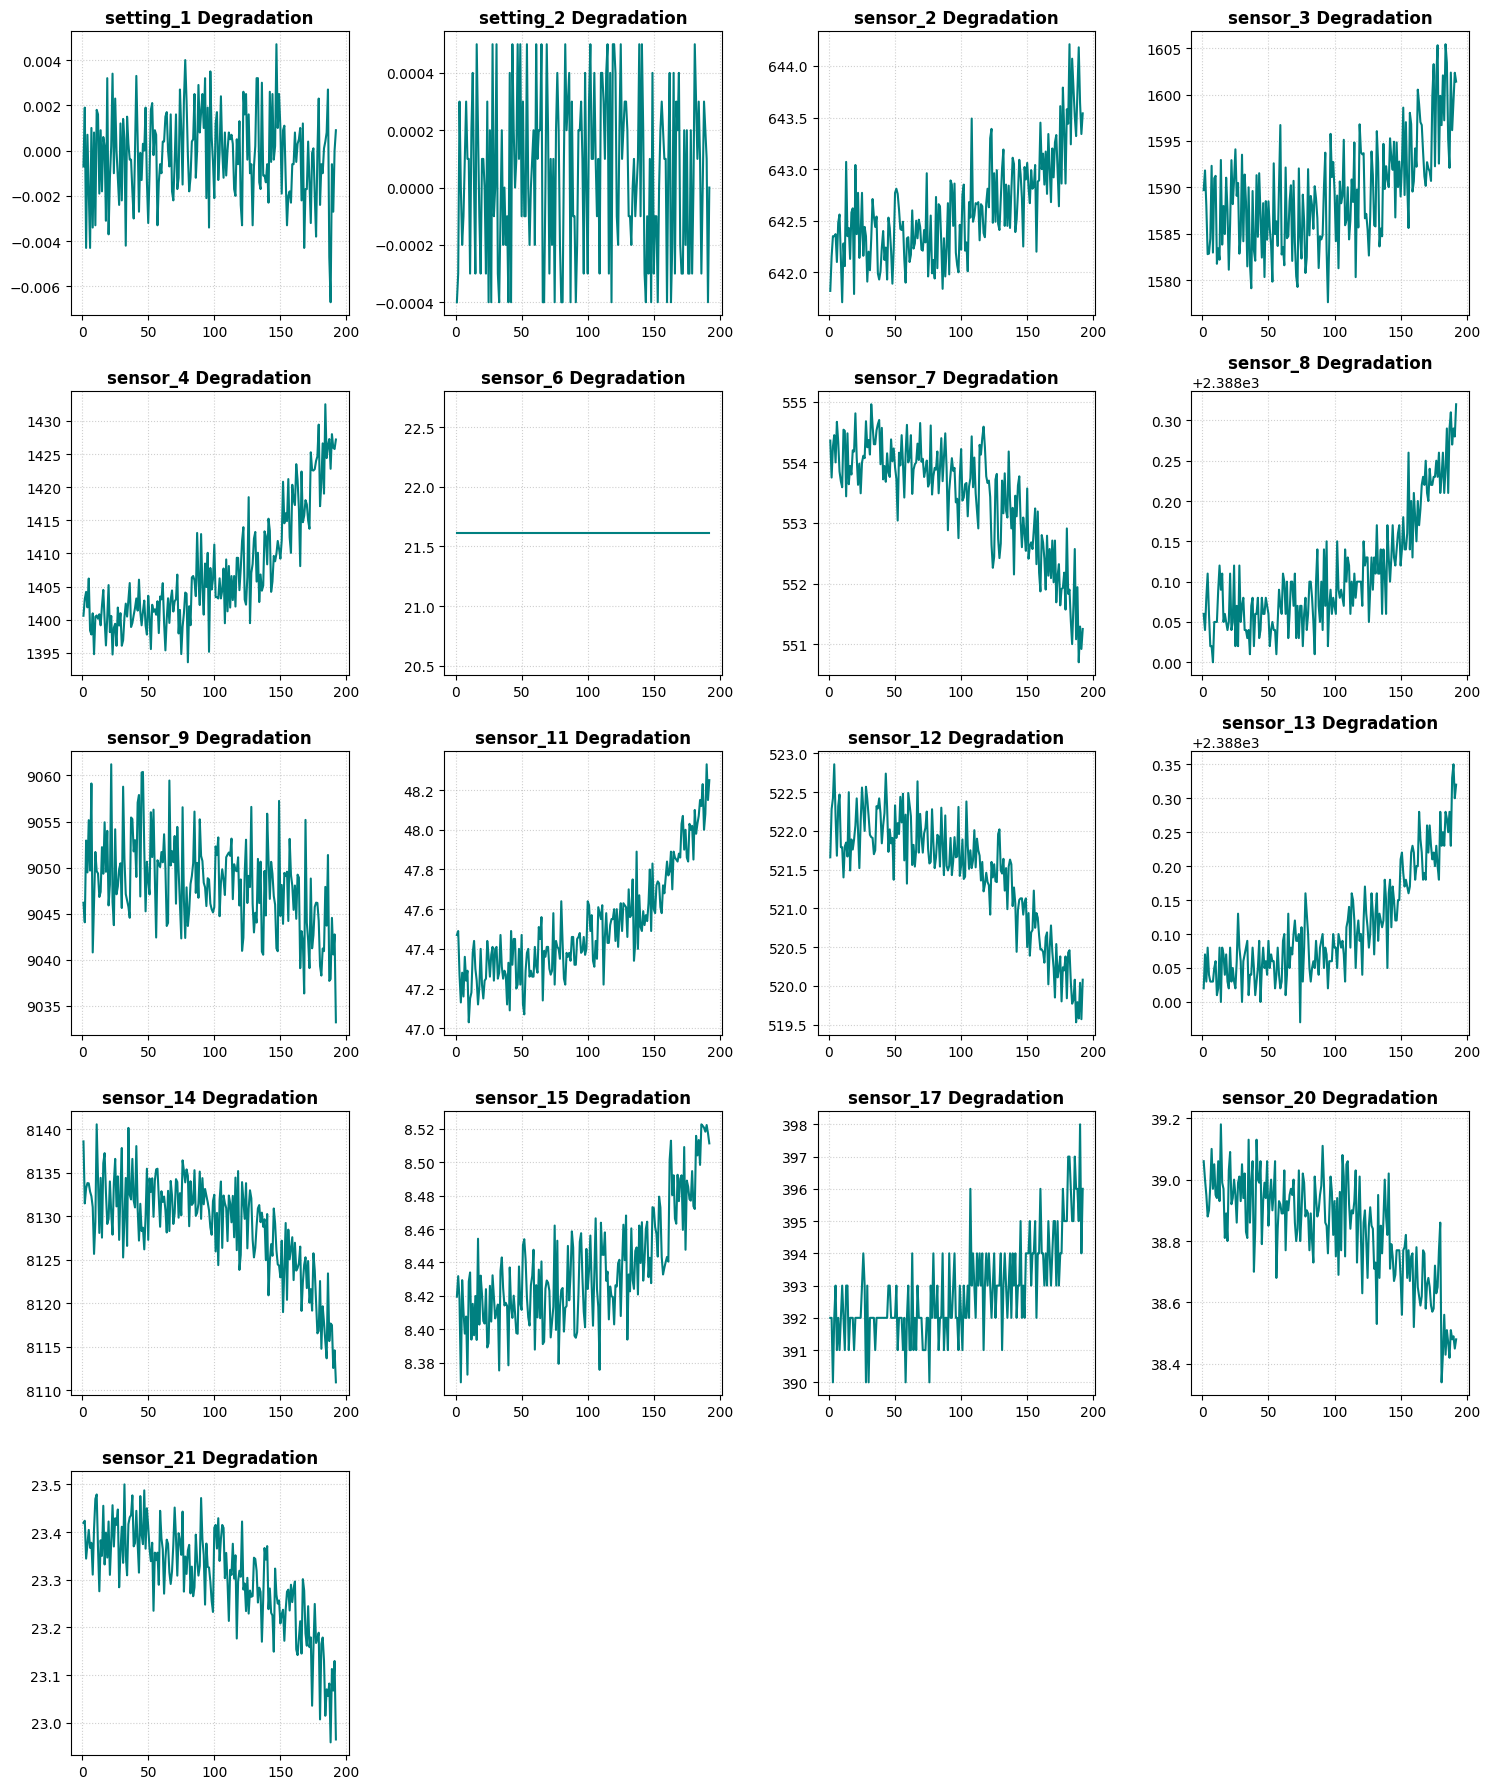

In [14]:
# 🔵 Phase 2: Data Cleaning
import matplotlib.pyplot as plt
sensors_to_plot = df_train_clean.columns.drop(['unit_number', 'time_cycles', 'RUL'])


engine_1 = df_train_clean[df_train_clean['unit_number'] == 1]
plt.figure(figsize=(15, 18))

# Loop through every single sensor and draw a mini-graph
for i, col in enumerate(sensors_to_plot, 1):
    plt.subplot(5, 4, i)
    plt.plot(engine_1['time_cycles'], engine_1[col], color='teal')
    plt.title(f"{col} Degradation", fontweight='bold')
    plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout() # This keeps the graphs from overlapping
plt.show()

In [15]:
# to see how strongly every single column is connected to 'RUL' target

correlation_math = df_train_clean.corr()['RUL'].sort_values(ascending=False)
print(correlation_math)


RUL            1.000000
sensor_12      0.671983
sensor_7       0.657223
sensor_21      0.635662
sensor_20      0.629428
unit_number    0.078753
setting_2     -0.001948
setting_1     -0.003198
sensor_6      -0.128348
sensor_14     -0.306769
sensor_9      -0.390102
sensor_13     -0.562569
sensor_8      -0.563968
sensor_3      -0.584520
sensor_17     -0.606154
sensor_2      -0.606484
sensor_15     -0.642667
sensor_4      -0.678948
sensor_11     -0.696228
time_cycles   -0.736241
Name: RUL, dtype: float64


In [16]:
#dropping unit number as it is not related to RUL
columns_to_drop_final = ['unit_number']
df_final = df_train_clean.drop(columns=columns_to_drop_final)

In [17]:
# 🔵Phase 3: Baseline Model
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Isolate the Target (The Answer Key)
y = df_train_clean['RUL']

# 2. Isolate the Features (The Evidence)
X = df_train_clean.drop(columns=['unit_number', 'time_cycles', 'RUL'])

# 3. Split the data- 80% for studying (train), 20% for the final exam (test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Scale the data so all sensors are on the same playing field
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
# Scale the test data, but DO NOT let the scaler learn from the test data.
X_test_scaled = scaler.transform(X_test)

print(f"Number of columns the AI is allowed to look at: {X_train.shape[1]}")
print(f"Total rows for training (studying): {X_train.shape[0]}")
print(f"Total rows for testing (the final exam): {X_test.shape[0]}")

Number of columns the AI is allowed to look at: 17
Total rows for training (studying): 16504
Total rows for testing (the final exam): 4127


In [18]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# n_estimators=100 means building 100 different decision trees and taking their average vote

model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

print("The AI is studying the translated data (Training)... ")
# STUDY THE STUDY GUIDE (Fit)
model.fit(X_train_scaled, y_train)

print("✍️ The AI is taking the Final Exam (Predicting)...")
# TAKE THE FINAL EXAM (Predict)
y_pred = model.predict(X_test_scaled)

# Final scores
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\n📊FINAL SCORES")
print(f"Mean Absolute Error (MAE): {mae:.2f} flights")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} flights")
print(f"R-Squared : {r2*100:.2f}%")

The AI is studying the translated data (Training)... 
✍️ The AI is taking the Final Exam (Predicting)...

📊FINAL SCORES
Mean Absolute Error (MAE): 29.63 flights
Root Mean Squared Error (RMSE): 41.46 flights
R-Squared : 62.38%


In [19]:
# 🔵Phase 4: RUL Optimization
#  THE PIECEWISE FIX (Clipping)
# Hyperparameter Optimization
caps_to_try = [100, 115, 125, 130, 150]

for cap in caps_to_try:

    df_temp = df_train_clean.copy()

    #  Apply cap
    df_temp['RUL'] = df_temp['RUL'].clip(upper=cap)

    #  Setup X and y USING df_temp (Not df_train_clean!)
    y_temp = df_temp['RUL']
    X_temp = df_temp.drop(columns=['unit_number', 'time_cycles', 'RUL'])

    #  Split the temp data
    X_train_temp, X_test_temp, y_train_temp, y_test_temp = train_test_split(
        X_temp, y_temp, test_size=0.2, random_state=42
    )

    #  Scale the temp data
    scaler_temp = StandardScaler()
    X_train_scaled_temp = scaler_temp.fit_transform(X_train_temp)
    X_test_scaled_temp = scaler_temp.transform(X_test_temp)

    #  Train the AI Brain
    model_temp = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
    model_temp.fit(X_train_scaled_temp, y_train_temp)

    #  Take the exam and grade it
    y_pred_temp = model_temp.predict(X_test_scaled_temp)
    mae_temp = mean_absolute_error(y_test_temp, y_pred_temp)
    r2_temp = r2_score(y_test_temp, y_pred_temp)

    #  Print (This must be indented inside the loop too!)
    print(f"🎯 Cap Level: {cap}")
    print(f"   MAE: {mae_temp:.2f} flights")
    print(f"   R-Squared: {r2_temp*100:.2f}%\n")



🎯 Cap Level: 100
   MAE: 8.69 flights
   R-Squared: 82.98%

🎯 Cap Level: 115
   MAE: 11.57 flights
   R-Squared: 80.68%

🎯 Cap Level: 125
   MAE: 13.62 flights
   R-Squared: 78.94%

🎯 Cap Level: 130
   MAE: 14.57 flights
   R-Squared: 78.26%

🎯 Cap Level: 150
   MAE: 18.65 flights
   R-Squared: 74.97%



In [20]:
# 🔵Phase 5: Feature Engineering (Experiments)
# FEATURE ENGINEERING
#Time-based features
# 1.Difference (current previous cycle)
sensor_cols = [c for c in df_train_clean.columns if 'sensor' in c]

# Calculate the 'Change' for each sensor
for col in sensor_cols:
    df_train_clean[f'{col}_diff'] = df_train_clean.groupby('unit_number')[col].diff()

print("✅ Speedometer (Difference) features added!")
print(f"Columns so far: {df_train_clean.shape[1]}")

✅ Speedometer (Difference) features added!
Columns so far: 35


In [21]:
for col in sensor_cols:
  # 2.Rolling mean (last 5 cycles avg sensor)
    # Average of last 5 flights (Smooths out the noise)
    df_train_clean[f'{col}_roll_mean'] = df_train_clean.groupby('unit_number')[col].rolling(window=5).mean().reset_index(0, drop=True)
  # 3.Rolling std (instability)
    # Standard Deviation of last 5 flights (Detects if the sensor is starting to 'shake')
    df_train_clean[f'{col}_roll_std'] = df_train_clean.groupby('unit_number')[col].rolling(window=5).std().reset_index(0, drop=True)

# 🚨 IMPORTANT: The first 4 flights of every engine don't have enough history,
# so they will have 'NaN' (empty) values. We fill them with 0.
df_train_clean = df_train_clean.fillna(0)

print(f"Columns so far: {df_train_clean.shape[1]}")

Columns so far: 65


In [22]:
# Define Engine Life Stages (Early, Mid, Late)
# This helps the AI understand that 'high heat' is scarier at Cycle 200 than Cycle 20.
def get_life_stage(cycle):
    if cycle <= 30: return 0   # early
    if cycle <= 80: return 1   # mid
    return 2                   # late

df_train_clean['life_stage'] = df_train_clean['time_cycles'].apply(get_life_stage)

# Fill any remaining NaNs with 0
df_train_clean = df_train_clean.fillna(0)

print(f"✅ Total Columns: {df_train_clean.shape[1]}")
df_train_clean.head()

✅ Total Columns: 66


,unit_number,time_cycles,setting_1,setting_2,sensor_2,sensor_3,sensor_4,sensor_6,sensor_7,sensor_8,...,sensor_14_roll_std,sensor_15_roll_mean,sensor_15_roll_std,sensor_17_roll_mean,sensor_17_roll_std,sensor_20_roll_mean,sensor_20_roll_std,sensor_21_roll_mean,sensor_21_roll_std,life_stage
0,1,1,-0.0007,-0.0004,641.82,1589.70,1400.60,21.61,554.36,2388.06,...,0.000000,0.00000,0.000000,0.0,0.000000,0.000,0.000000,0.00000,0.000000,0
1,1,2,0.0019,-0.0003,642.15,1591.82,1403.14,21.61,553.75,2388.04,...,0.000000,0.00000,0.000000,0.0,0.000000,0.000,0.000000,0.00000,0.000000,0
2,1,3,-0.0043,0.0003,642.35,1587.99,1404.20,21.61,554.26,2388.08,...,0.000000,0.00000,0.000000,0.0,0.000000,0.000,0.000000,0.00000,0.000000,0
3,1,4,0.0007,0.0000,642.35,1582.79,1401.87,21.61,554.45,2388.11,...,0.000000,0.00000,0.000000,0.0,0.000000,0.000,0.000000,0.00000,0.000000,0
4,1,5,-0.0019,-0.0002,642.37,1582.85,1406.22,21.61,554.00,2388.06,...,2.651326,8.41334,0.025953,391.8,1.095445,38.958,0.073621,23.39302,0.033498,0


In [23]:
# 🔵 Phase 6: Model Comparison
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
print(" TESTING NEW FEATURES ON Random Forest...\n")


df_temp = df_train_clean.copy()
useless_cols = ['setting_1', 'setting_2', 'sensor_6']
df_temp = df_temp.drop(columns=useless_cols, errors='ignore')

#Setup X and y
y_temp = df_temp['RUL']
X_temp = df_temp.drop(columns=['unit_number', 'time_cycles', 'RUL'])

#Split
X_train_temp, X_test_temp, y_train_temp, y_test_temp = train_test_split(
    X_temp, y_temp, test_size=0.2, random_state=42
)

# Scale
scaler_temp = StandardScaler()
X_train_scaled = scaler_temp.fit_transform(X_train_temp)
X_test_scaled = scaler_temp.transform(X_test_temp)

# Train
rf_model_new_features = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
rf_model_new_features.fit(X_train_scaled, y_train_temp)

#Grade it
y_pred_rf = rf_model_new_features.predict(X_test_scaled)
mae_rf = mean_absolute_error(y_test_temp, y_pred_rf)
r2_rf = r2_score(y_test_temp, y_pred_rf)


print(f"🎯 New RF MAE : {mae_rf:.2f} flights\n")

print(f"🎯 New RF R-Squared: {r2_rf*100:.2f}%")


 TESTING NEW FEATURES ON Random Forest...

🎯 New RF MAE : 21.43 flights

🎯 New RF R-Squared: 79.49%


In [24]:
import pandas as pd

print(" SCANNING THE CONFUSED AI'S BRAIN...\n")

# 1. Extract the importance scores from struggling model
importance_scores_new = rf_model_new_features.feature_importances_

# 2. Create the massive 65-feature leaderboard
feature_leaderboard_new = pd.DataFrame({
    'Feature': X_temp.columns, # Using X_temp because it has all 65 names
    'Importance_Percentage': importance_scores_new * 100
})

# 3. Sort from MVP down to Absolute Garbage
feature_leaderboard_new = feature_leaderboard_new.sort_values(by='Importance_Percentage', ascending=False)

# 4. Print the extremes!
print("🏆 THE TOP 10 MVPs (The signals that actually help):")
print(feature_leaderboard_new.head(10).to_string(index=False))

print("\n🗑️ THE BOTTOM 5 WORST (The pure noise confusing the AI):")
print(feature_leaderboard_new.tail(5).to_string(index=False))

 SCANNING THE CONFUSED AI'S BRAIN...

🏆 THE TOP 10 MVPs (The signals that actually help):
            Feature  Importance_Percentage
         life_stage              48.257422
sensor_11_roll_mean               9.773244
 sensor_4_roll_mean               8.722842
sensor_15_roll_mean               4.007120
 sensor_9_roll_mean               3.136879
sensor_14_roll_mean               2.148190
sensor_12_roll_mean               1.384620
 sensor_7_roll_mean               1.115399
 sensor_3_roll_mean               1.078440
sensor_21_roll_mean               0.974865

🗑️ THE BOTTOM 5 WORST (The pure noise confusing the AI):
           Feature  Importance_Percentage
         sensor_17               0.091913
    sensor_17_diff               0.084009
 sensor_6_roll_std               0.035367
sensor_6_roll_mean               0.025808
     sensor_6_diff               0.018608


In [25]:
df_lean = df_train_clean.copy()

noisy_math = [c for c in df_lean.columns if '_diff' in c or '_roll_std' in c]


useless = ['setting_1', 'setting_2', 'sensor_6']
useless_clones = [c for c in df_lean.columns if 'sensor_6' in c]

# Combine all the trash into one giant garbage bag
all_trash = list(set(noisy_math + useless + useless_clones))

# Drop it
df_lean = df_lean.drop(columns=all_trash, errors='ignore')

print(f"🗑️ Trashed {len(all_trash)} noisy columns!")
print(f"✨ New Lean Dataset Columns: {df_lean.shape[1]}")

🗑️ Trashed 34 noisy columns!
✨ New Lean Dataset Columns: 32


In [26]:
print(df_lean.columns)

Index(['unit_number', 'time_cycles', 'sensor_2', 'sensor_3', 'sensor_4',
       'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12',
       'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20',
       'sensor_21', 'RUL', 'sensor_2_roll_mean', 'sensor_3_roll_mean',
       'sensor_4_roll_mean', 'sensor_7_roll_mean', 'sensor_8_roll_mean',
       'sensor_9_roll_mean', 'sensor_11_roll_mean', 'sensor_12_roll_mean',
       'sensor_13_roll_mean', 'sensor_14_roll_mean', 'sensor_15_roll_mean',
       'sensor_17_roll_mean', 'sensor_20_roll_mean', 'sensor_21_roll_mean',
       'life_stage'],
      dtype='object')


In [27]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


# 1. Setup X and y using our newly purified dataset
y_lean = df_lean['RUL']
X_lean = df_lean.drop(columns=['unit_number', 'time_cycles', 'RUL'])

# 2. Split
X_train_lean, X_test_lean, y_train_lean, y_test_lean = train_test_split(
    X_lean, y_lean, test_size=0.2, random_state=42
)

# 3. Scale
scaler_lean = StandardScaler()
X_train_scaled_lean = scaler_lean.fit_transform(X_train_lean)
X_test_scaled_lean = scaler_lean.transform(X_test_lean)

# 4. Train
rf_model_lean = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
rf_model_lean.fit(X_train_scaled_lean, y_train_lean)

# 5. Grade the exam
y_pred_lean = rf_model_lean.predict(X_test_scaled_lean)
mae_lean = mean_absolute_error(y_test_lean, y_pred_lean)
r2_lean = r2_score(y_test_lean, y_pred_lean)


print(f"🎯 LEAN MAE : {mae_lean:.2f} flights\n")

print(f"🎯 LEAN R-Squared: {r2_lean*100:.2f}%")

🎯 LEAN MAE : 21.97 flights

🎯 LEAN R-Squared: 78.41%


In [28]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print(" (Top 20 Features)...\n")

# 1. Grab the exact names of the Top 20 features from our brain scan leaderboard
top_20_features = feature_leaderboard_new.head(20)['Feature'].tolist()

# 2. Slice the dataset to ONLY include these 20 VIPs
X_goldilocks = X_temp[top_20_features]
y_goldilocks = df_temp['RUL']

# 3. Split
X_train_gold, X_test_gold, y_train_gold, y_test_gold = train_test_split(
    X_goldilocks, y_goldilocks, test_size=0.2, random_state=42
)

# 4. Scale
scaler_gold = StandardScaler()
X_train_scaled_gold = scaler_gold.fit_transform(X_train_gold)
X_test_scaled_gold = scaler_gold.transform(X_test_gold)

# 5. Train
rf_model_gold = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
rf_model_gold.fit(X_train_scaled_gold, y_train_gold)

# 6. Grade the exam
y_pred_gold = rf_model_gold.predict(X_test_scaled_gold)
mae_gold = mean_absolute_error(y_test_gold, y_pred_gold)
r2_gold = r2_score(y_test_gold, y_pred_gold)


print(f" MAE (Top 20 columns): {mae_gold:.2f} flights\n")
print(f" R-Squared: {r2_gold*100:.2f}%")

 (Top 20 Features)...

 MAE (Top 20 columns): 19.48 flights

 R-Squared: 82.58%


In [29]:
from xgboost import XGBRegressor

# learning_rate=0.1 tells it to take careful, calculated steps so it doesn't overthink
xgb_model_gold = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, n_jobs=-1)

# Train it on the EXACT SAME Top-20 scaled data
xgb_model_gold.fit(X_train_scaled_gold, y_train_gold)

# Grade the final exam
y_pred_xgb_gold = xgb_model_gold.predict(X_test_scaled_gold)
mae_xgb_gold = mean_absolute_error(y_test_gold, y_pred_xgb_gold)
r2_xgb_gold = r2_score(y_test_gold, y_pred_xgb_gold)



print(f"FINAL XGBOOST MAE: {mae_xgb_gold:.2f} flights ")
print(f"FINAL XGBOOST R-Squared: {r2_xgb_gold*100:.2f}% ")

FINAL XGBOOST MAE: 22.31 flights 
FINAL XGBOOST R-Squared: 78.56% 


In [30]:

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print(" ESTABLISHING THE OFFICIAL BASELINE (Pure Data + Random Forest)...\n")

# 1. Ensure we only have the pure original columns (Filtering out the messy experiments)
pure_sensors = [c for c in df_train_clean.columns if 'sensor' in c and 'roll' not in c and 'diff' not in c]
cols_to_keep = ['unit_number', 'time_cycles', 'RUL'] + pure_sensors
df_pure = df_train_clean[cols_to_keep].copy()

# 2. Run the exact baseline loop
caps_to_try = [100, 115, 125, 130, 150]

for cap in caps_to_try:
    df_temp = df_pure.copy()

    # Apply cap
    df_temp['RUL'] = df_temp['RUL'].clip(upper=cap)

    # Setup X and y
    y_temp = df_temp['RUL']
    X_temp = df_temp.drop(columns=['unit_number', 'time_cycles', 'RUL'])

    # Split
    X_train_temp, X_test_temp, y_train_temp, y_test_temp = train_test_split(
        X_temp, y_temp, test_size=0.2, random_state=42
    )

    # Scale
    scaler_temp = StandardScaler()
    X_train_scaled_temp = scaler_temp.fit_transform(X_train_temp)
    X_test_scaled_temp = scaler_temp.transform(X_test_temp)

    # Train
    model_temp = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
    model_temp.fit(X_train_scaled_temp, y_train_temp)

    # Grade it
    y_pred_temp = model_temp.predict(X_test_scaled_temp)
    mae_temp = mean_absolute_error(y_test_temp, y_pred_temp)
    r2_temp = r2_score(y_test_temp, y_pred_temp)

    print(f"🎯 Cap Level: {cap}")
    print(f"   MAE: {mae_temp:.2f} flights")
    print(f"   R-Squared: {r2_temp*100:.2f}%\n")

 ESTABLISHING THE OFFICIAL BASELINE (Pure Data + Random Forest)...

🎯 Cap Level: 100
   MAE: 8.68 flights
   R-Squared: 83.03%

🎯 Cap Level: 115
   MAE: 11.54 flights
   R-Squared: 80.74%

🎯 Cap Level: 125
   MAE: 13.59 flights
   R-Squared: 78.99%

🎯 Cap Level: 130
   MAE: 14.62 flights
   R-Squared: 78.26%

🎯 Cap Level: 150
   MAE: 18.55 flights
   R-Squared: 75.20%



In [31]:
from xgboost import XGBRegressor

print(" THE FINAL LAP: XGBOOST VS BASELINE...\n")

# 1. Setup the perfect, pure 100-capped dataset
df_final = df_pure.copy()
df_final['RUL'] = df_final['RUL'].clip(upper=100)

X_final = df_final.drop(columns=['unit_number', 'time_cycles', 'RUL'])
y_final = df_final['RUL']

# 2. Split & Scale
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(X_final, y_final, test_size=0.2, random_state=42)

scaler_f = StandardScaler()
X_train_scaled_f = scaler_f.fit_transform(X_train_f)
X_test_scaled_f = scaler_f.transform(X_test_f)

# 3. Train
xgb_final = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, n_jobs=-1)
xgb_final.fit(X_train_scaled_f, y_train_f)

# 4. Grade the Final Exam
y_pred_xgb_f = xgb_final.predict(X_test_scaled_f)
mae_xgb_f = mean_absolute_error(y_test_f, y_pred_xgb_f)
r2_xgb_f = r2_score(y_test_f, y_pred_xgb_f)

print(f"🎯 Official RF Baseline: 8.68 flights")

print(f" FINAL XGBOOST MAE: {mae_xgb_f:.2f} flights")
print(f" FINAL XGBOOST R-Squared: {r2_xgb_f*100:.2f}%")

 THE FINAL LAP: XGBOOST VS BASELINE...

🎯 Official RF Baseline: 8.68 flights
 FINAL XGBOOST MAE: 8.46 flights
 FINAL XGBOOST R-Squared: 83.27%


In [32]:
# 🔵 Phase 7: FINAL MODEL
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
print(" TESTING NEW FEATURES ON Random Forest...\n")

#🚨 THE FIX: Permanently lock in the winning Cap (100)
df_train_clean['RUL'] = df_train_clean['RUL'].clip(upper=100)

# Now when the computer copies the data, it copies the clipped version
df_temp = df_train_clean.copy()
useless_cols = ['setting_1', 'setting_2', 'sensor_6']
df_temp = df_temp.drop(columns=useless_cols, errors='ignore')

#Setup X and y
y_temp = df_temp['RUL']
X_temp = df_temp.drop(columns=['unit_number', 'time_cycles', 'RUL'])

#Split
X_train_temp, X_test_temp, y_train_temp, y_test_temp = train_test_split(
    X_temp, y_temp, test_size=0.2, random_state=42
)

# Scale
scaler_temp = StandardScaler()
X_train_scaled = scaler_temp.fit_transform(X_train_temp)
X_test_scaled = scaler_temp.transform(X_test_temp)

# Train
rf_model_new_features = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
rf_model_new_features.fit(X_train_scaled, y_train_temp)

#Grade it
y_pred_rf = rf_model_new_features.predict(X_test_scaled)
mae_rf = mean_absolute_error(y_test_temp, y_pred_rf)
r2_rf = r2_score(y_test_temp, y_pred_rf)


print(f"🎯 New RF MAE : {mae_rf:.2f} flights\n")

print(f"🎯 New RF R-Squared: {r2_rf*100:.2f}%")

 TESTING NEW FEATURES ON Random Forest...

🎯 New RF MAE : 6.35 flights

🎯 New RF R-Squared: 89.23%


In [35]:
import joblib


joblib.dump(rf_model_new_features, 'random_forest_rul_model.pkl')

joblib.dump(scaler_temp, 'rul_scaler.pkl')

rf_features = X_temp.columns
joblib.dump(rf_features, 'rf_sensor_columns.pkl')

print("✅ SUCCESS! 3 files saved to your Colab environment:")
print("  1. random_forest_rul_model.pkl")
print("  2. rul_scaler.pkl")
print("  3. rf_sensor_columns.pkl")

✅ SUCCESS! 3 files saved to your Colab environment:
  1. random_forest_rul_model.pkl
  2. rul_scaler.pkl
  3. rf_sensor_columns.pkl
